In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.impute import SimpleImputer
from scipy.stats import probplot
from scipy.stats import spearmanr


# Ensure image output directory exists and provide a helper to save figures
IMG_DIR = os.path.abspath(os.path.join('..', '..', 'Rapport_TP', 'images', 'Soil'))
os.makedirs(IMG_DIR, exist_ok=True)

def savefig(name: str, dpi: int = 200, tight: bool = True):
    base, ext = os.path.splitext(name)
    if not ext:
        ext = '.png'
    path = os.path.join(IMG_DIR, f"{base}{ext}")

    # if target exists, replace
    if os.path.exists(path):
        os.remove(path)
    if tight:
        try:
            plt.tight_layout()
        except Exception:
            pass
    # remove existing file to avoid caching issues on some systems
    try:
        os.remove(path)
    except Exception:
        pass
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Replaced figure: {path}")
    print(f"Saved figure: {path}")


In [2]:
# loading soil dataset
df_soil = pd.read_csv('../../ExtractedDatasets/SoilFeatures/hwsd2_grid01_D1.csv')

In [3]:
df_soil.shape

(23262, 27)

In [4]:
#df_soil memory usage
print("Soil Data Memory Usage:", df_soil.memory_usage(deep=True).sum() / (1024 ** 2), "MB")

Soil Data Memory Usage: 5.9011688232421875 MB


In [5]:
df_soil.describe()

,y,x,band,spatial_ref,HWSD2_SMU_ID,COARSE,SAND,SILT,CLAY,TEXTURE_USDA,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
count,23262.000000,23262.000000,23262.0,23262.0,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,17782.000000,...,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000,23262.000000
mean,28.566299,3.150593,1.0,0.0,3308.185625,7.777534,39.715115,21.707678,12.355300,9.630806,...,8.509028,43.752343,25.178961,22.522913,68.225948,-0.871378,2.249678,6.534232,0.993225,0.160261
std,4.448850,4.574674,0.0,0.0,7843.976730,7.955769,26.359172,15.604824,10.159885,1.759534,...,7.841284,29.658153,21.244188,22.015838,42.064991,1.723344,7.149722,6.691281,6.634088,2.835915
min,18.991667,-8.616667,1.0,0.0,36.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,25.091667,-0.116667,1.0,0.0,193.000000,3.000000,31.000000,6.000000,6.000000,9.000000,...,5.000000,35.000000,12.000000,10.000000,64.000000,0.000000,1.000000,0.000000,0.100000,0.000000
50%,28.391667,3.483333,1.0,0.0,1645.000000,12.000000,49.000000,27.000000,16.000000,9.000000,...,13.000000,52.000000,30.000000,30.000000,97.000000,0.000000,3.000000,8.000000,0.300000,1.000000
75%,32.191667,6.783333,1.0,0.0,1833.000000,12.000000,57.000000,33.000000,18.000000,11.000000,...,14.000000,68.000000,38.000000,38.000000,100.000000,0.000000,3.000000,11.300000,0.700000,1.000000
max,37.491667,11.983333,1.0,0.0,32050.000000,46.000000,90.000000,46.000000,55.000000,12.000000,...,41.000000,83.000000,143.000000,143.000000,100.000000,40.000000,67.000000,27.900000,57.599998,32.000000


In [6]:
df_soil.columns

Index(['y', 'x', 'band', 'spatial_ref', 'HWSD2_SMU_ID', 'COARSE', 'SAND',
       'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK',
       'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY',
       'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM',
       'ELEC_COND'],
      dtype='object')

In [7]:
#columns values and counts

for col in ["band","spatial_ref","PH_WATER"]:
    print("Column:", col)
    print(df_soil[col].value_counts())
    print("\n")

Column: band
band
1    23262
Name: count, dtype: int64


Column: spatial_ref
spatial_ref
0    23262
Name: count, dtype: int64


Column: PH_WATER
PH_WATER
 8.2    6761
 7.4    4174
-4.0    3916
 7.8    3254
 8.0    1597
-3.0    1427
 7.9     613
 8.1     259
 6.7     255
 6.1     244
 7.7     196
 8.5     186
-5.0     120
 7.5      49
 6.9      41
 6.8      37
 7.3      22
 6.4      22
 8.6      13
-9.0      12
 6.3      12
 5.7      11
 6.5      11
 5.3      10
 5.9       6
-1.0       5
 7.6       4
 7.1       4
 5.1       1
Name: count, dtype: int64




In [8]:
#drop band column
df_soil = df_soil.drop(columns=["band","spatial_ref"])

In [9]:
nominal_columns = ["TEXTURE_USDA", "TEXTURE_SOTER"]
numeric_cols = ["COARSE", "SAND", "SILT", "CLAY", "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO", "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", "ESP", "TCARBON_EQ", "GYPSUM", "ELEC_COND", "PH_WATER"]


In [10]:
# functionto calculate % of missing values
def missing_percentage(df):
    missing_count = df.isnull().sum().sum()
    total_count = df.size
    return (missing_count / total_count) * 100

In [11]:
#pourcentage of missing values in soil dataset
print(missing_percentage(df_soil),"%")

1.88461869142808 %


In [12]:
# extracting soil empty rows
df_missing_soil = df_soil[df_soil.isnull().any(axis=1)]

print("Number of rows with missing soil data:", df_missing_soil.shape[0])

Number of rows with missing soil data: 5480


In [13]:
# percentage of missing values in df_missing_soil for each column
print(df_missing_soil.isnull().mean() * 100)

y                  0.0
x                  0.0
HWSD2_SMU_ID       0.0
COARSE             0.0
SAND               0.0
SILT               0.0
CLAY               0.0
TEXTURE_USDA     100.0
TEXTURE_SOTER      0.0
BULK               0.0
REF_BULK         100.0
ORG_CARBON         0.0
PH_WATER           0.0
TOTAL_N            0.0
CN_RATIO           0.0
CEC_SOIL           0.0
CEC_CLAY           0.0
CEC_EFF            0.0
TEB                0.0
BSAT               0.0
ALUM_SAT           0.0
ESP                0.0
TCARBON_EQ         0.0
GYPSUM             0.0
ELEC_COND          0.0
dtype: float64


In [14]:
# check in df_missing_soil if  TEXTURE_USDA is missing  REF_BULK is not vise versa

print("Rows where both TEXTURE_USDA and REF_BULK are missing:")
# rows where both TEXTURE_USDA and REF_BULK are NOT missing (negative form: NOT)
print(df_missing_soil[(~(df_missing_soil['TEXTURE_USDA'].notnull()) & (df_missing_soil['REF_BULK'].notnull())) | (~(df_missing_soil['REF_BULK'].notnull()) & (df_missing_soil['TEXTURE_USDA'].notnull()))])


Rows where both TEXTURE_USDA and REF_BULK are missing:
Empty DataFrame
Columns: [y, x, HWSD2_SMU_ID, COARSE, SAND, SILT, CLAY, TEXTURE_USDA, TEXTURE_SOTER, BULK, REF_BULK, ORG_CARBON, PH_WATER, TOTAL_N, CN_RATIO, CEC_SOIL, CEC_CLAY, CEC_EFF, TEB, BSAT, ALUM_SAT, ESP, TCARBON_EQ, GYPSUM, ELEC_COND]
Index: []

[0 rows x 25 columns]


In [15]:
#index of rows with missing soil data
missing_soil_indices = df_missing_soil.index.tolist()

print(missing_soil_indices)

[17, 140, 141, 142, 151, 152, 217, 218, 231, 1244, 1251, 1484, 1485, 1609, 1610, 1615, 2523, 3594, 3595, 3597, 3598, 3599, 3710, 3717, 3718, 3719, 3720, 3721, 3722, 3836, 3839, 3840, 3844, 3845, 3846, 3847, 3963, 3964, 3968, 3971, 3972, 4090, 4091, 4095, 4097, 4098, 4099, 4100, 4101, 4102, 4218, 4219, 4222, 4223, 4224, 4226, 4227, 4228, 4230, 4347, 4348, 4350, 4351, 4352, 4353, 4354, 4355, 4356, 4478, 4479, 4480, 4481, 4482, 4483, 4484, 4485, 4486, 4487, 4610, 4611, 4612, 4613, 4614, 4615, 4616, 4617, 4618, 4619, 4626, 4627, 4741, 4742, 4744, 4745, 4746, 4747, 4748, 4749, 4750, 4751, 4752, 4753, 4754, 4755, 4756, 4757, 4758, 4759, 4762, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884, 4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 5010, 5011, 5012, 5013, 5014, 5015, 5016, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5136, 5137, 5138, 5140, 5141, 5142, 5143, 5144, 5145, 5146, 5147, 5148, 5149, 5150, 5151, 5152, 5153, 5216, 5264, 5265, 5266, 5267, 5269, 5270, 5271, 5272, 5273, 5

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_texture_refbulk.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_texture_refbulk.png


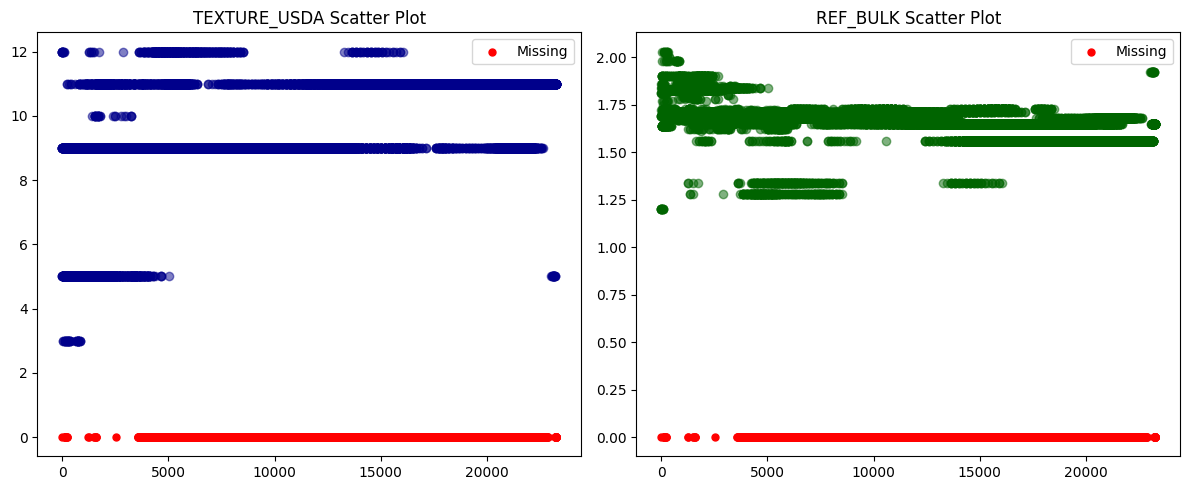

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TEXTURE_USDA
axes[0].scatter(df_soil.index, df_soil['TEXTURE_USDA'], color='darkblue', alpha=0.5)
axes[0].scatter(missing_soil_indices, [0] * len(missing_soil_indices),
                color='red', s=25, label='Missing')
axes[0].set_title("TEXTURE_USDA Scatter Plot")
axes[0].legend()

# REF_BULK
axes[1].scatter(df_soil.index, df_soil['REF_BULK'], color='darkgreen', alpha=0.5)
axes[1].scatter(missing_soil_indices, [0] * len(missing_soil_indices),
                color='red', s=25, label='Missing')
axes[1].set_title("REF_BULK Scatter Plot")
axes[1].legend()

plt.tight_layout()
savefig('soil_scatter_texture_refbulk.png')
plt.show()


In [17]:
#mean mode median of TEXTURE_USDA and REF_BULK
for col in ["TEXTURE_USDA", "REF_BULK"]:
    if col in df_soil.columns:
        mean_val = df_soil[col].mean()
        median_val = df_soil[col].median()
        mode_val = df_soil[col].mode()[0] if not df_soil[col].mode().empty else None
        print(f"{col} - Mean: {mean_val}, Median: {median_val}, Mode: {mode_val}")
    else:
        print(f"Column {col} not found in the dataset.")

TEXTURE_USDA - Mean: 9.630806433472051, Median: 9.0, Mode: 11.0
REF_BULK - Mean: 1.6557237422918123, Median: 1.6799999475479126, Mode: 1.6799999475479126


Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_texture_refbulk.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_texture_refbulk.png


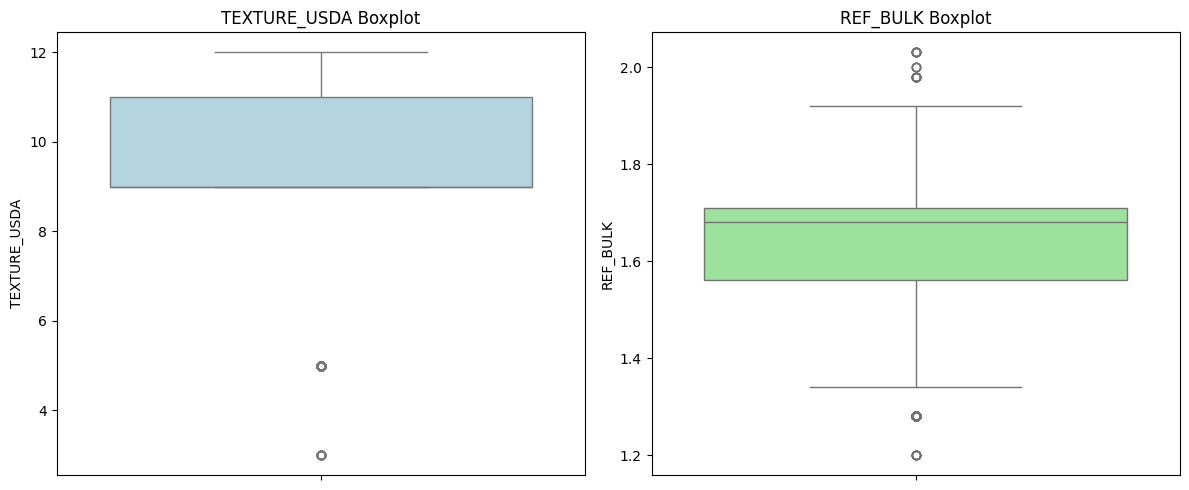

In [18]:
# boxplot values of TEXTURE_USDA and REF_BULK
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_soil['TEXTURE_USDA'], ax=axes[0], color='lightblue')
axes[0].set_title("TEXTURE_USDA Boxplot")
sns.boxplot(y=df_soil['REF_BULK'], ax=axes[1], color='lightgreen')
axes[1].set_title("REF_BULK Boxplot")
plt.tight_layout()
savefig('soil_boxplots_texture_refbulk.png')
plt.show()

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda.png


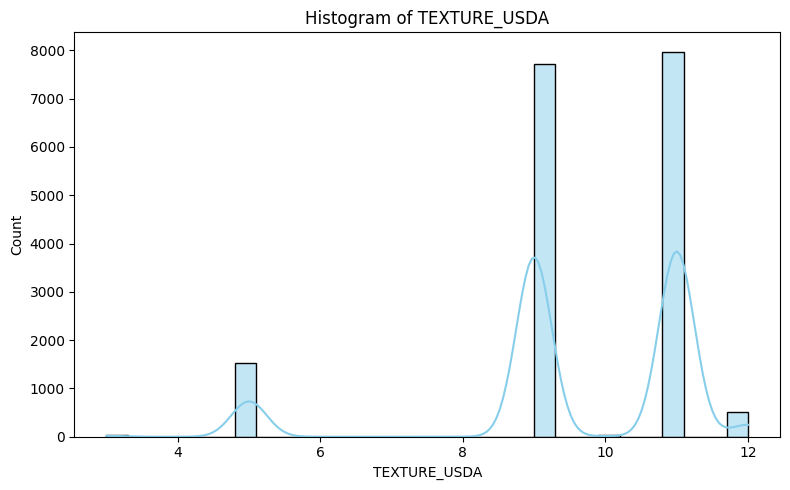

In [19]:
#histogram of TEXTURE_USDA
plt.figure(figsize=(8, 5))
sns.histplot(df_soil['TEXTURE_USDA'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Histogram of TEXTURE_USDA")
plt.xlabel('TEXTURE_USDA')
plt.ylabel('Count')
savefig('soil_hist_texture_usda.png')
plt.show()

In [20]:
# check in df_missing_soil if  TEXTURE_USDA is missing  REF_BULK is not vise versa

print("Rows where both TEXTURE_USDA and REF_BULK are missing:")
# rows where both TEXTURE_USDA and REF_BULK are NOT missing (negative form: NOT)
print(df_missing_soil[(~(df_missing_soil['TEXTURE_USDA'].notnull()) & (df_missing_soil['REF_BULK'].notnull())) | (~(df_missing_soil['REF_BULK'].notnull()) & (df_missing_soil['TEXTURE_USDA'].notnull()))])


Rows where both TEXTURE_USDA and REF_BULK are missing:
Empty DataFrame
Columns: [y, x, HWSD2_SMU_ID, COARSE, SAND, SILT, CLAY, TEXTURE_USDA, TEXTURE_SOTER, BULK, REF_BULK, ORG_CARBON, PH_WATER, TOTAL_N, CN_RATIO, CEC_SOIL, CEC_CLAY, CEC_EFF, TEB, BSAT, ALUM_SAT, ESP, TCARBON_EQ, GYPSUM, ELEC_COND]
Index: []

[0 rows x 25 columns]


Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_ecdf_ref_bulk.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_ecdf_ref_bulk.png


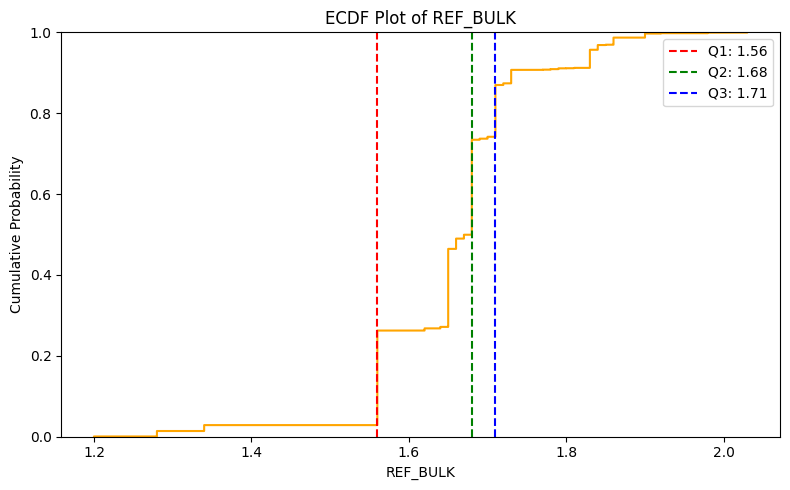

In [21]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(df_soil['REF_BULK'].dropna(), color='orange')
plt.title("ECDF Plot of REF_BULK")

# Calculate quartiles
ref_bulk_clean = df_soil['REF_BULK'].dropna()
q1 = ref_bulk_clean.quantile(0.25)
q2 = ref_bulk_clean.quantile(0.50)  # median
q3 = ref_bulk_clean.quantile(0.75)

# Add vertical lines for quartiles
plt.axvline(q1, color='red', linestyle='--', linewidth=1.5, label=f'Q1: {q1:.2f}')
plt.axvline(q2, color='green', linestyle='--', linewidth=1.5, label=f'Q2: {q2:.2f}')
plt.axvline(q3, color='blue', linestyle='--', linewidth=1.5, label=f'Q3: {q3:.2f}')

plt.xlabel('REF_BULK')
plt.ylabel('Cumulative Probability')
plt.legend()
savefig('soil_ecdf_ref_bulk.png')
plt.show()

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk.png


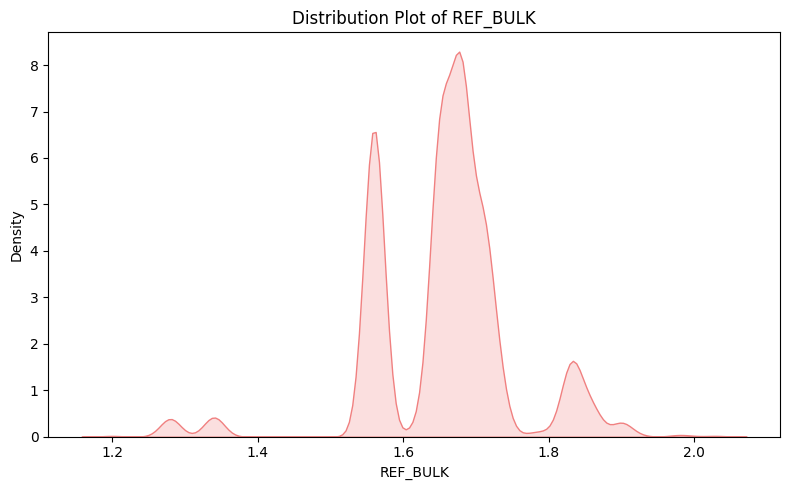

In [22]:
#distribution plot of REF_BULK
plt.figure(figsize=(8, 5))
sns.kdeplot(df_soil['REF_BULK'].dropna(), fill=True, color='lightcoral')
plt.title("Distribution Plot of REF_BULK")
plt.xlabel('REF_BULK')
plt.ylabel('Density')
savefig('soil_kde_ref_bulk.png')
plt.show()

## removing missing values

In [23]:
#simple imputer (median) for REF_Bulk
imputer = SimpleImputer(strategy='median')
df_soil['REF_BULK'] = imputer.fit_transform(df_soil[['REF_BULK']])

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk_after_imputation.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_kde_ref_bulk_after_imputation.png


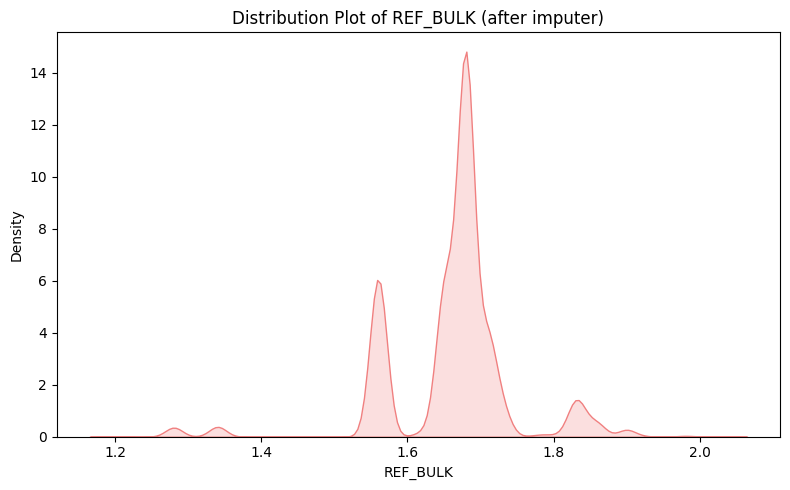

In [24]:
#distribution plot of REF_BULK
plt.figure(figsize=(8, 5))
sns.kdeplot(df_soil['REF_BULK'].dropna(), fill=True, color='lightcoral')
plt.title("Distribution Plot of REF_BULK (after imputer)")
savefig('soil_kde_ref_bulk_after_imputation.png')


In [25]:
# Known classes only
known = df_soil[df_soil['TEXTURE_USDA'].notna()].copy()
known['TEXTURE_USDA'] = known['TEXTURE_USDA'].astype(int)

# distribution
counts = known['TEXTURE_USDA'].value_counts().sort_index()
print("Class min:", counts.index.min(), " Class max:", counts.index.max())
print(counts)


Class min: 3  Class max: 12
TEXTURE_USDA
3       37
5     1517
9     7717
10      26
11    7974
12     511
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# features to use for centroid calculation
features = ['SAND', 'SILT', 'CLAY']

# select known rows
known = df_soil[df_soil['TEXTURE_USDA'].notna()].copy()
known['TEXTURE_USDA'] = known['TEXTURE_USDA'].astype(int)

# scale features for fair comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(known[features])

# add scaled features back for mean computation
known_scaled = pd.DataFrame(X_scaled, columns=features, index=known.index)
known_scaled['TEXTURE_USDA'] = known['TEXTURE_USDA']

# compute centroid (mean per class)
centroids = known_scaled.groupby('TEXTURE_USDA')[features].mean()
print("Centroids (mean composition per class):")
print(centroids)


Centroids (mean composition per class):
                  SAND      SILT      CLAY
TEXTURE_USDA                              
3            -3.071266  0.639618  5.895361
5            -1.597866  0.837086  2.374710
9            -0.608907  0.777486  0.275428
10           -0.136714 -0.875670  1.503820
11            0.717967 -0.707282 -0.612346
12            2.964820 -3.191287 -2.157137


In [27]:
# rows with missing TEXTURE_USDA
missing = df_soil[df_soil['TEXTURE_USDA'].isna()].copy()

# scale their features using same scaler
X_missing = scaler.transform(missing[features])

# compute Euclidean distance to each centroid
distances = cdist(X_missing, centroids.values, metric='euclidean')

# pick nearest class
nearest_class = centroids.index[np.argmin(distances, axis=1)]

# fill missing values
df_soil.loc[missing.index, 'TEXTURE_USDA'] = nearest_class


In [28]:
print("Remaining NaNs:", df_soil['TEXTURE_USDA'].isna().sum())

# new class distribution
dist_after = df_soil['TEXTURE_USDA'].astype(int).value_counts().sort_index()
print("\nNew class distribution after smart imputation:")
print(dist_after)


Remaining NaNs: 0

New class distribution after smart imputation:
TEXTURE_USDA
3        37
5      1517
9      7717
10       26
11    13454
12      511
Name: count, dtype: int64


Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda_after_imputer.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hist_texture_usda_after_imputer.png


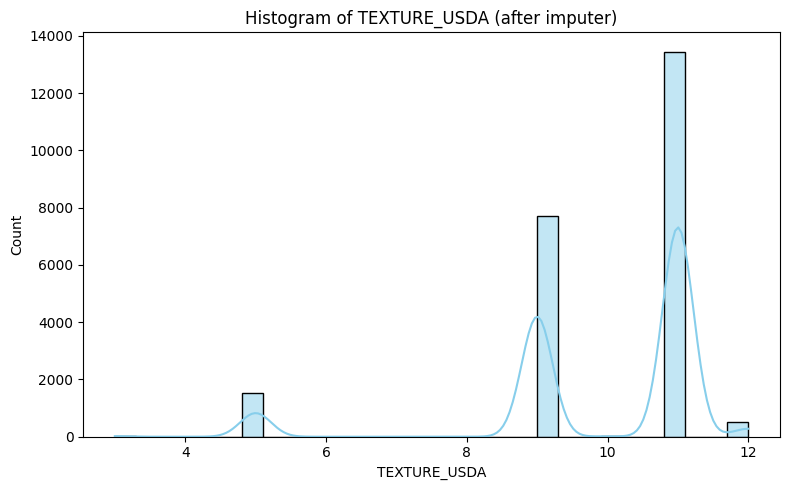

In [29]:
#histogram of TEXTURE_USDA
plt.figure(figsize=(8, 5))
sns.histplot(df_soil['TEXTURE_USDA'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Histogram of TEXTURE_USDA (after imputer)")
plt.xlabel('TEXTURE_USDA')
plt.ylabel('Count')
savefig('soil_hist_texture_usda_after_imputer.png')
plt.show()

# Data analysis

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_numeric.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_scatter_numeric.png


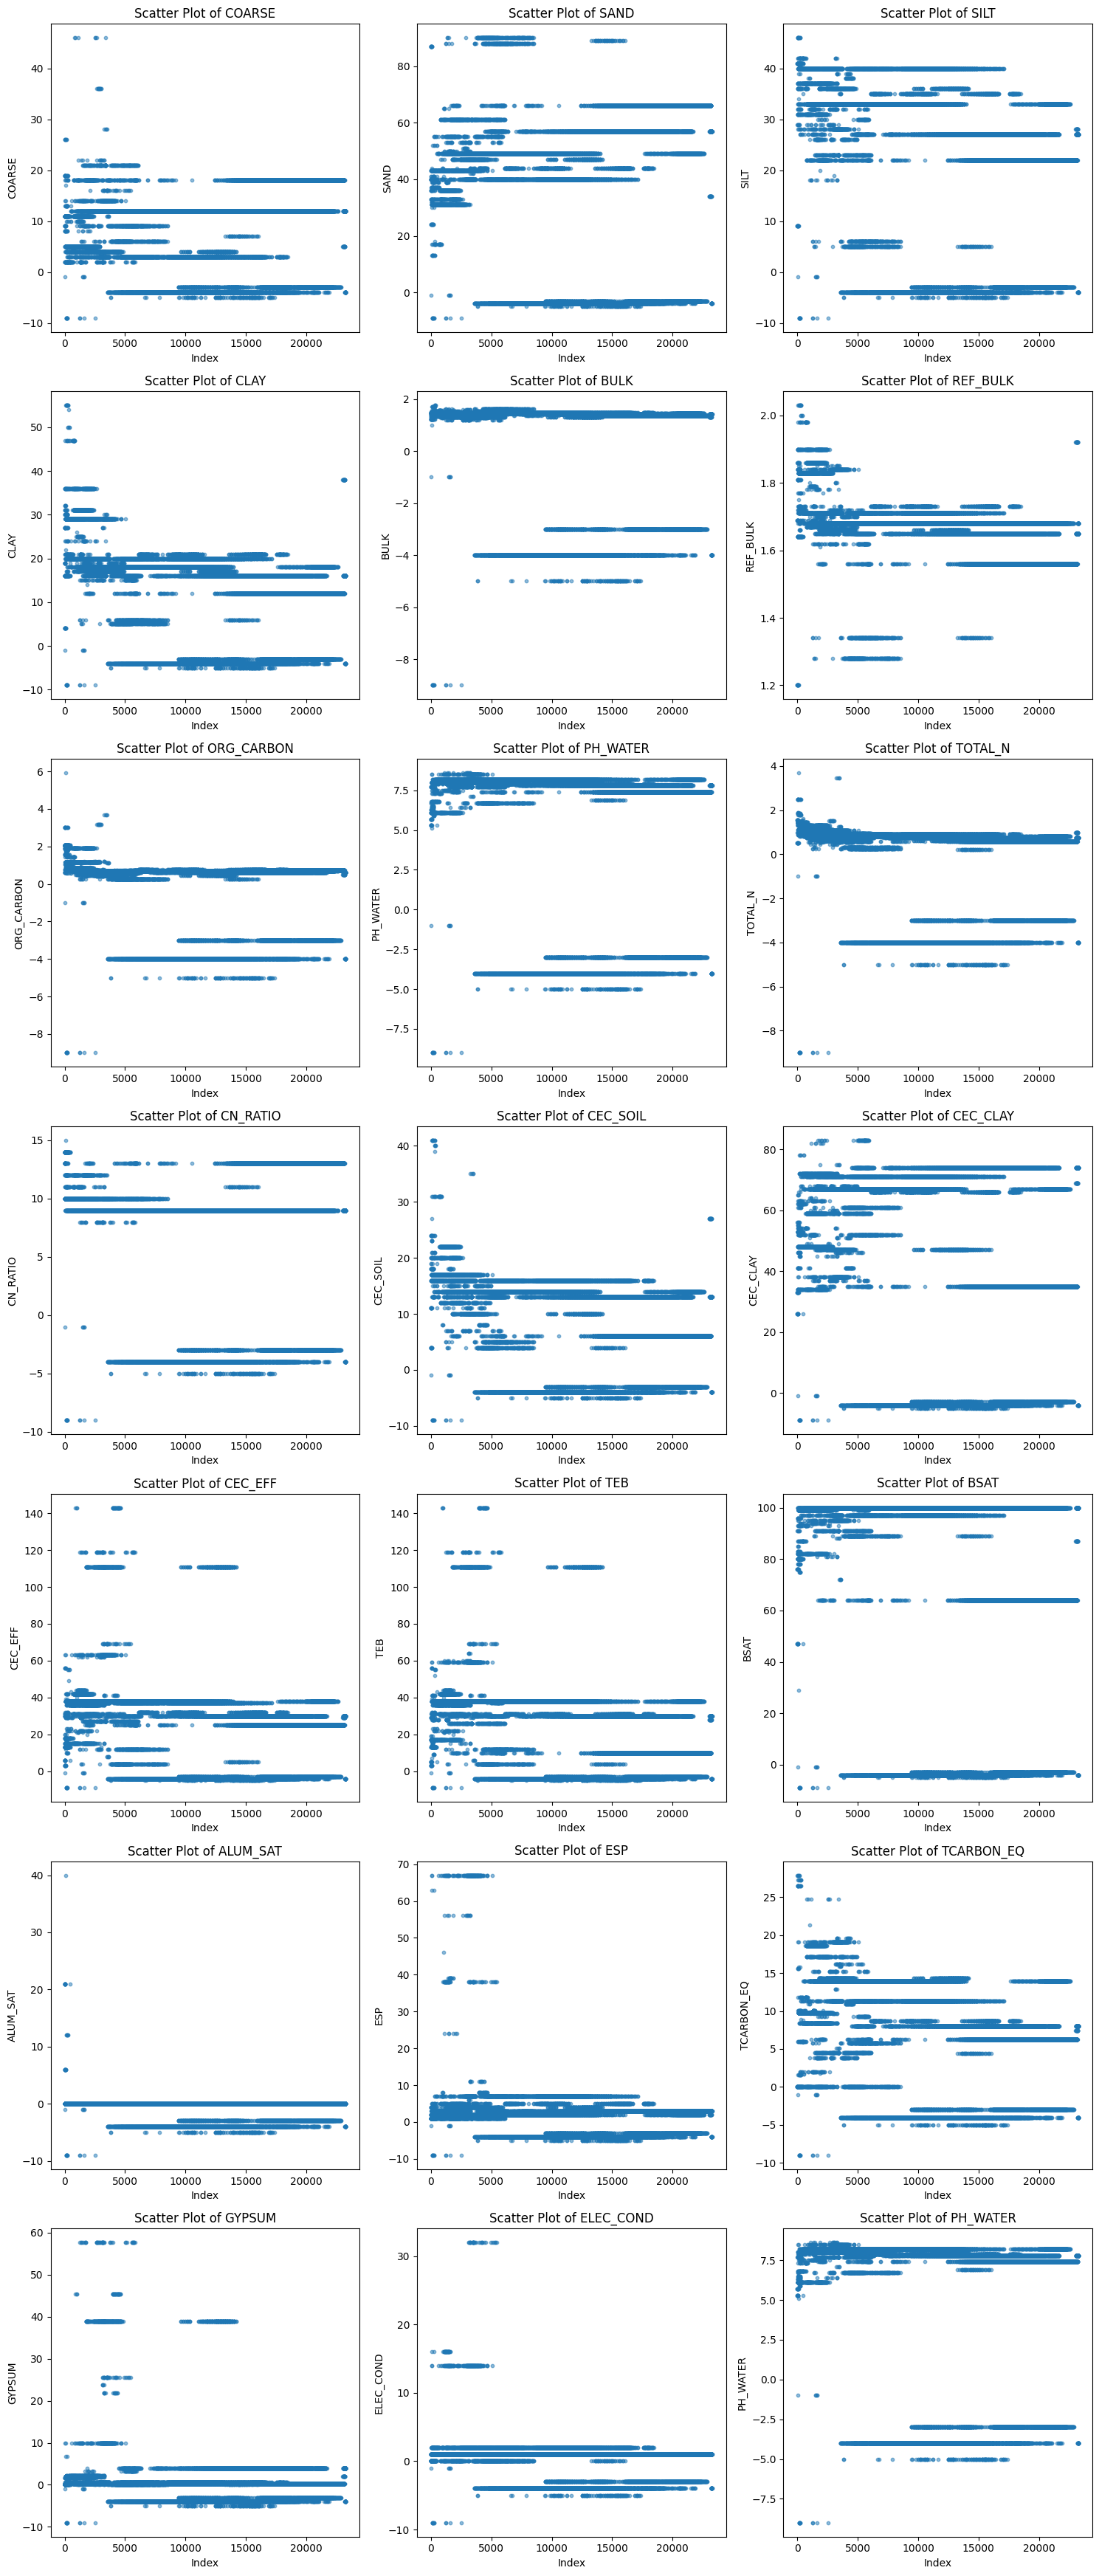

In [30]:
# Create subplots for numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 columns per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df_soil.index, df_soil[col], alpha=0.5, s=10)
    axes[i].set_title(f"Scatter Plot of {col}")
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel(col)

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
savefig('soil_scatter_numeric.png')
plt.show()

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_numeric.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_boxplots_numeric.png


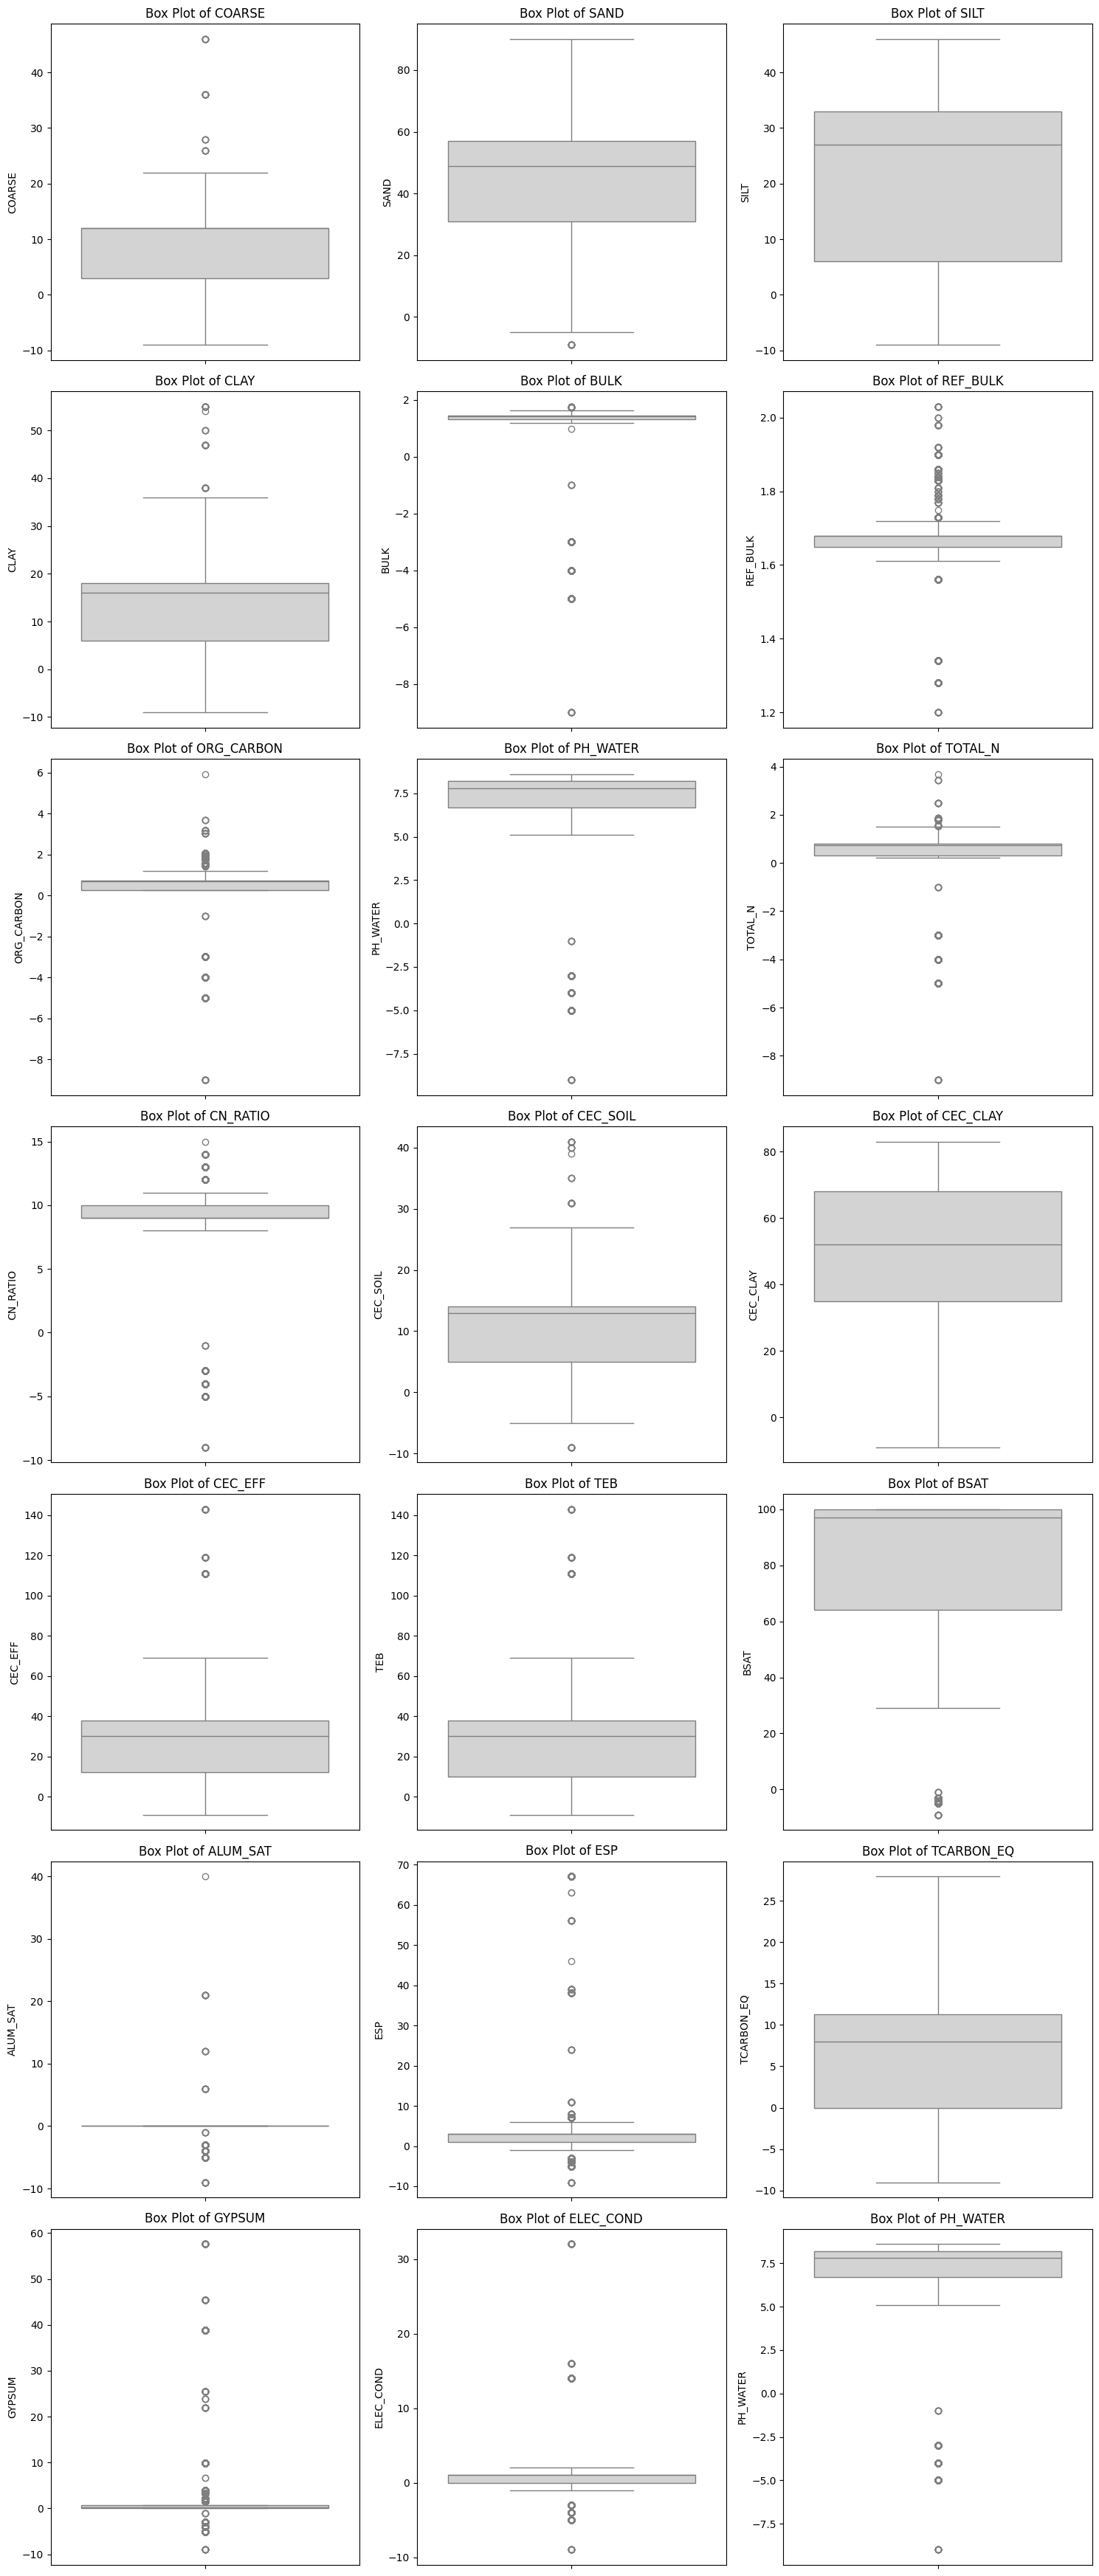

In [31]:
# box plots for numeric columns
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes_flat = axes_box.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_soil[col], ax=axes_flat[i], color='lightgray')
    axes_flat[i].set_title(f"Box Plot of {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel(col)

# Hide any unused axes (safety)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
savefig('soil_boxplots_numeric.png')
plt.show()

Replaced figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hitograms_numeric.png
Saved figure: d:\DataMining\Fire-Detection-Data-Mining-Project\Rapport_TP\images\Soil\soil_hitograms_numeric.png


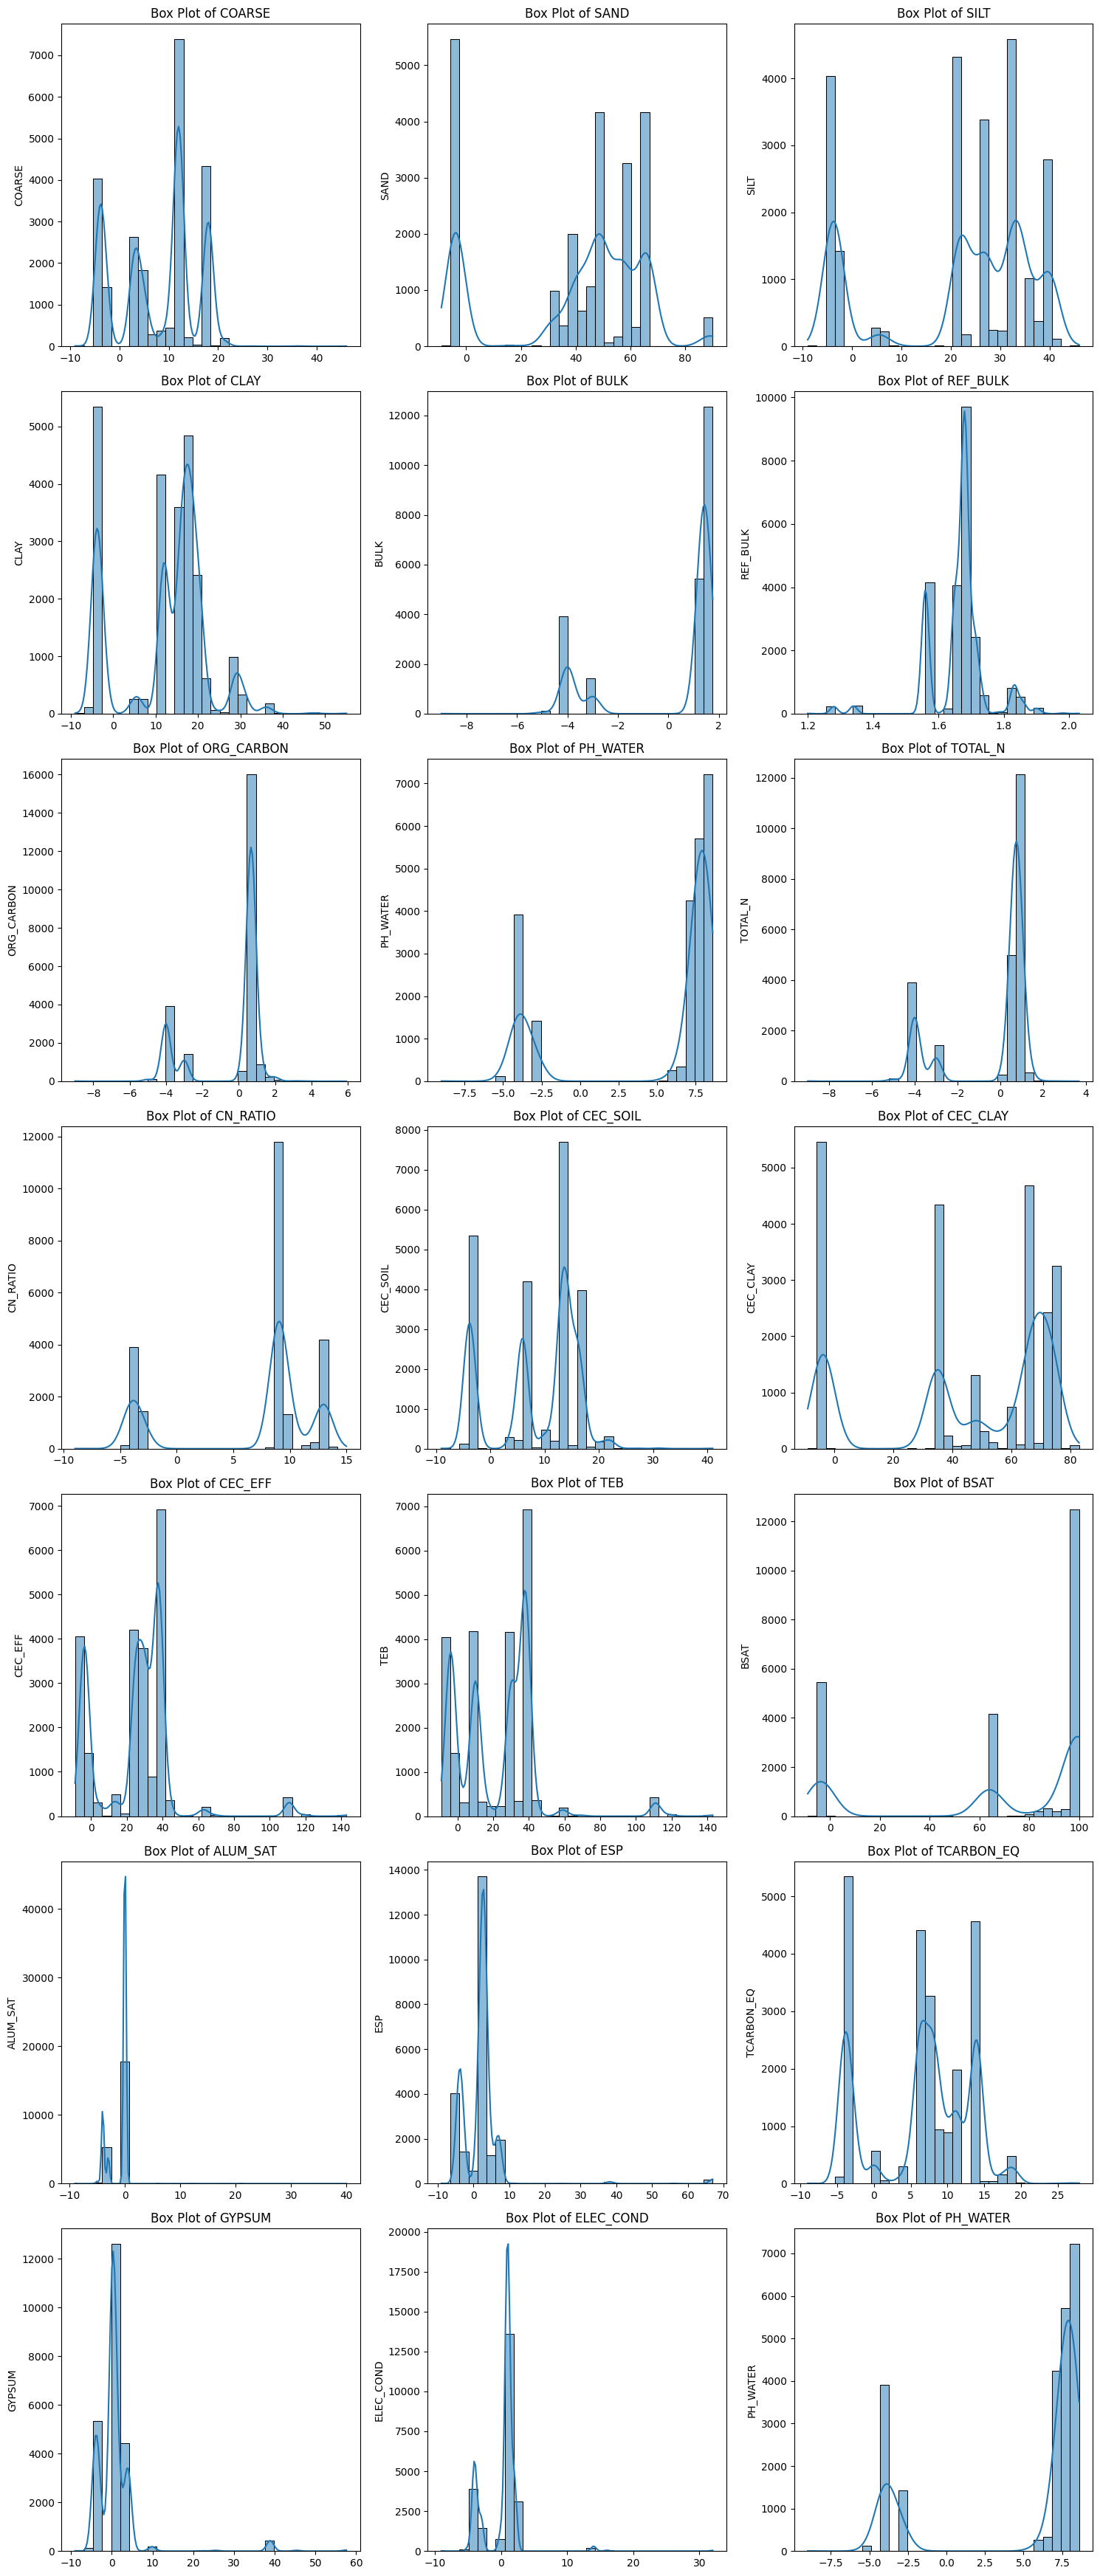

In [32]:
# histogram for numeric columns
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes_flat = axes_box.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_soil[col].dropna(), bins=30, kde=True, ax=axes_flat[i])
    axes_flat[i].set_title(f"Box Plot of {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel(col)

# Hide any unused axes (safety)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
savefig('soil_hitograms_numeric.png')
plt.show()

## Outliers

In [33]:
def remove_outliers_iqr(df, columns=None, multiplier=1.5, verbose=True):
    """
    Removes outliers from numerical columns using the IQR (Interquartile Range) method.
    
    Parameters
    ----------
    df : pd.DataFrame
        The input DataFrame.
    columns : list, optional
        List of column names to apply IQR filtering.
        If None, all numeric columns are processed.
    multiplier : float, optional (default=1.5)
        The IQR multiplier. Common values:
          - 1.5 = standard
          - 3.0 = conservative (fewer removed)
    verbose : bool
        If True, prints summary of removed rows per column.

    Returns
    -------
    pd.DataFrame
        DataFrame with outliers removed.
    """

    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()

    df_clean = df.copy()
    total_removed = 0

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        removed = before - len(df_clean)
        total_removed += removed
        
        if verbose and removed > 0:
            print(f"Column '{col}': removed {removed} outliers (bounds: {lower_bound:.2f}, {upper_bound:.2f})")

    if verbose:
        print(f"\n Total rows removed: {total_removed}")
        print(f"Remaining rows: {len(df_clean)}")

    return df_clean


In [34]:
columns_outlies = ["COARSE", "SAND", "CLAY","CEC_EFF"]
# Apply outlier removal
df_soil_clean = remove_outliers_iqr(df_soil, columns=columns_outlies, multiplier=1.5)

# Check the shape difference
print("Before:", df_soil.shape, "→ After:", df_soil_clean.shape)

Column 'COARSE': removed 28 outliers (bounds: -10.50, 25.50)
Column 'SAND': removed 12 outliers (bounds: -8.00, 96.00)
Column 'CLAY': removed 53 outliers (bounds: -12.00, 36.00)
Column 'CEC_EFF': removed 506 outliers (bounds: -27.00, 77.00)

 Total rows removed: 599
Remaining rows: 22663
Before: (23262, 25) → After: (22663, 25)


In [35]:
# Count and list invalid EC values
invalid = df_soil[df_soil['ELEC_COND'] < 0]['ELEC_COND']
print("Number of negative EC values:", invalid.shape[0])
print("Range of invalid EC values:", invalid.min(), "→", invalid.max())


Number of negative EC values: 5480
Range of invalid EC values: -9 → -1


In [36]:
df_soil['ELEC_COND'] = df_soil['ELEC_COND'].clip(lower=0)

In [37]:
# Count and list invalid pH values
invalid_ph = df_soil[(df_soil['PH_WATER'] < 3.5) | (df_soil['PH_WATER'] > 9.5)]['PH_WATER']
print("Number of invalid pH values:", invalid_ph.shape[0])
print("Range of invalid pH values:", invalid_ph.min(), "→", invalid_ph.max())


Number of invalid pH values: 5480
Range of invalid pH values: -9.0 → -1.0


After correction: 3.5 → 9.0


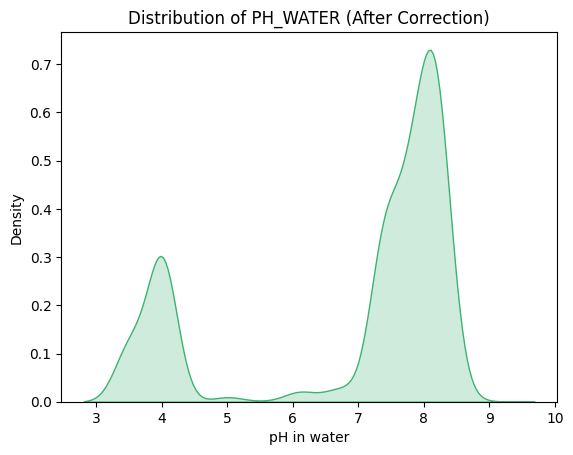

In [38]:
# Fix negative pH values by absolute correction
df_soil['PH_WATER'] = df_soil['PH_WATER'].abs()

# Optional: clip extreme corrected values to realistic soil range
df_soil['PH_WATER'] = df_soil['PH_WATER'].clip(lower=3.5, upper=9.5)

# Verify
print("After correction:", df_soil['PH_WATER'].min(), "→", df_soil['PH_WATER'].max())
sns.kdeplot(df_soil['PH_WATER'], fill=True, color='mediumseagreen')
plt.title("Distribution of PH_WATER (After Correction)")
plt.xlabel("pH in water")
plt.show()


In [42]:
#pearson correlation function
def pearsonSpearman(df, col1, col2):
    correlation, p_value = pearsonr(df[col1].dropna(), df[col2].dropna())
    print(f"Pearson correlation between {col1} and {col2}: {correlation:.4f} (p-value: {p_value:.4e})")
    spearman_corr, spearman_p = spearmanr(df[col1].dropna(), df[col2].dropna())
    print(f"Spearman correlation between {col1} and {col2}: {spearman_corr:.4f} (p-value: {spearman_p:.4f}) (p-value: {spearman_p:.4e})")

In [43]:
def corrPlot(df, col1, col2):
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Scatter plot
    axes[0].scatter(df[col1], df[col2], alpha=0.5, s=20, color='steelblue')
    axes[0].set_xlabel(f'{col1}')
    axes[0].set_ylabel(f'{col2}')
    axes[0].set_title(f'Scatter Plot: {col1} vs {col2}')
    axes[0].grid(True, alpha=0.3)

    # Add diagonal reference line
    min_val = min(df[col1].min(), df[col2].min())
    max_val = max(df[col1].max(), df[col2].max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    axes[0].legend()

    # Right: Q-Q plot (comparing sorted quantiles of BULK vs REF_BULK)
    col1_sorted = np.sort(df[col1].dropna())
    col2_sorted = np.sort(df[col2].dropna())

    # Match lengths by using minimum length
    min_len = min(len(col1_sorted), len(col2_sorted))
    col1_sorted = col1_sorted[:min_len]
    col2_sorted = col2_sorted[:min_len]

    axes[1].scatter(col1_sorted, col2_sorted, alpha=0.5, s=20, color='coral')
    axes[1].plot([col1_sorted.min(), col1_sorted.max()], 
                [col2_sorted.min(), col2_sorted.max()], 
                'r--', linewidth=2, label='Perfect match')
    axes[1].set_xlabel(f'{col1} (sorted quantiles)')
    axes[1].set_ylabel(f'{col2} (sorted quantiles)')
    axes[1].set_title(f'Q-Q Plot: {col1} vs {col2}')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'soil_{col1}_vs_{col2}_scatter_qq.png')
    plt.show()

Pearson correlation between BULK and REF_BULK: -0.1125 (p-value: 2.4501e-66)
Spearman correlation between BULK and REF_BULK: 0.3000 (p-value: 0.0000) (p-value: 0.0000e+00)


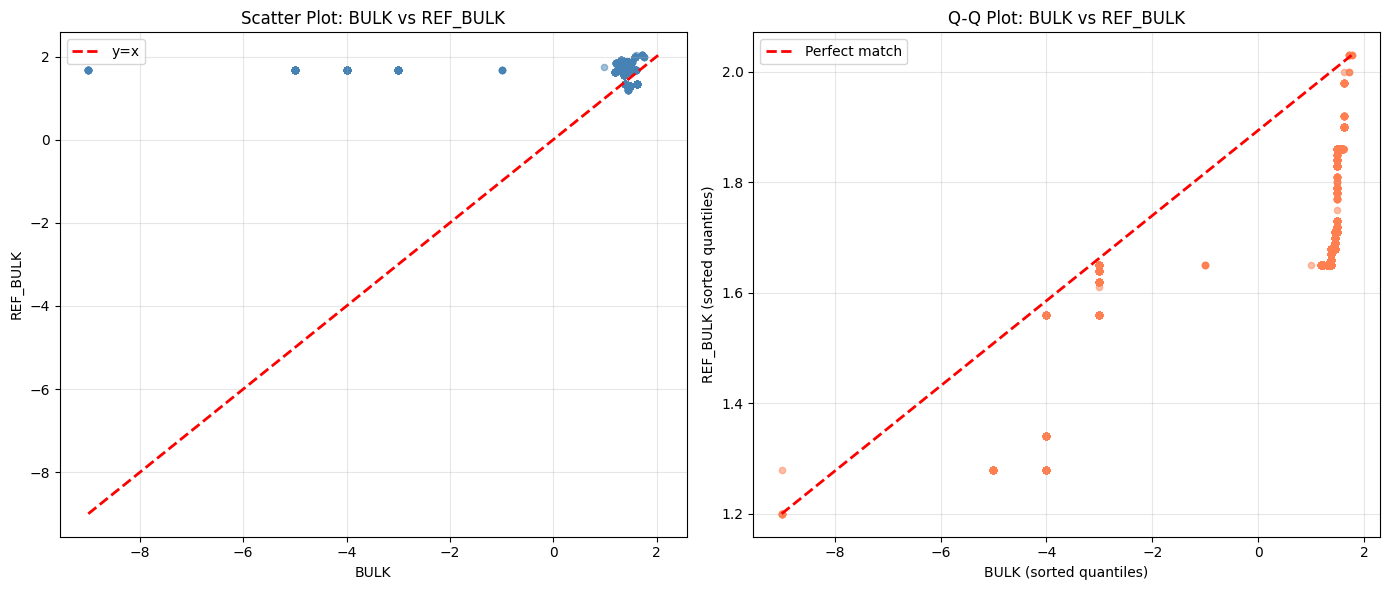

In [44]:
pearsonSpearman(df_soil, 'BULK', 'REF_BULK')
corrPlot(df_soil, 'BULK', 'REF_BULK')

Pearson correlation between ORG_CARBON and TOTAL_N: 0.9973 (p-value: 0.0000e+00)
Spearman correlation between ORG_CARBON and TOTAL_N: 0.6314 (p-value: 0.0000) (p-value: 0.0000e+00)


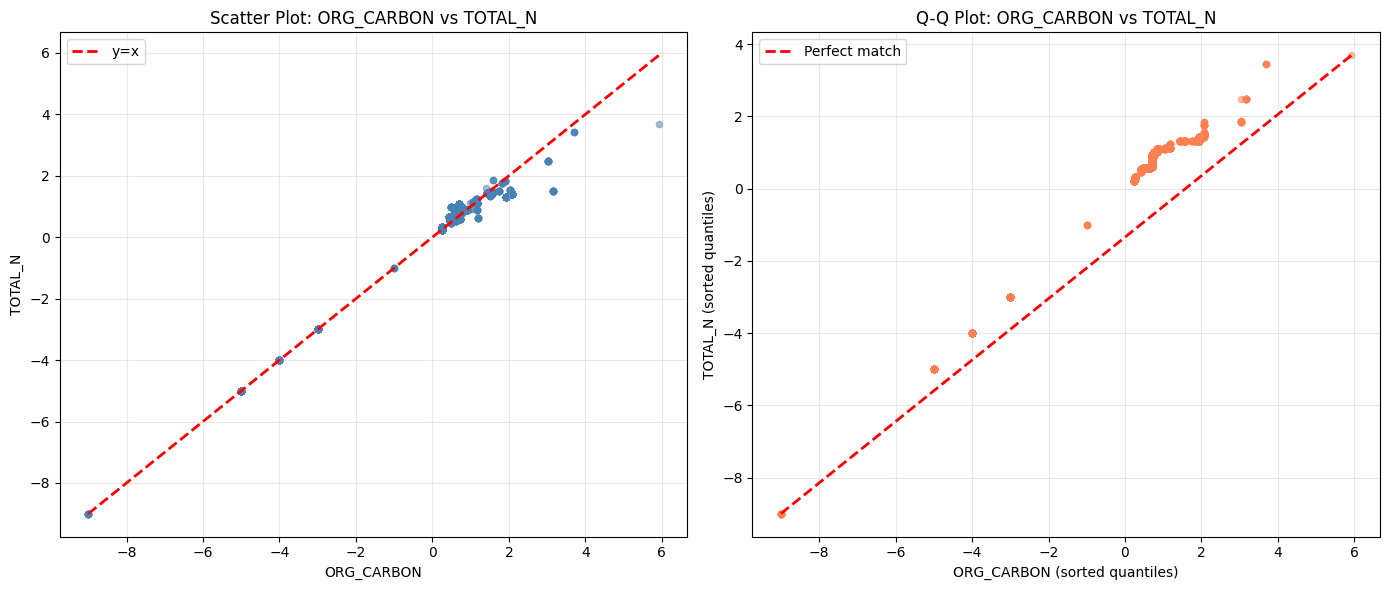

In [49]:
pearsonSpearman(df_soil, 'ORG_CARBON', 'TOTAL_N')
corrPlot(df_soil, 'ORG_CARBON', 'TOTAL_N')

Pearson correlation between CEC_SOIL and TEB: 0.7494 (p-value: 0.0000e+00)
Spearman correlation between CEC_SOIL and TEB: 0.8940 (p-value: 0.0000) (p-value: 0.0000e+00)


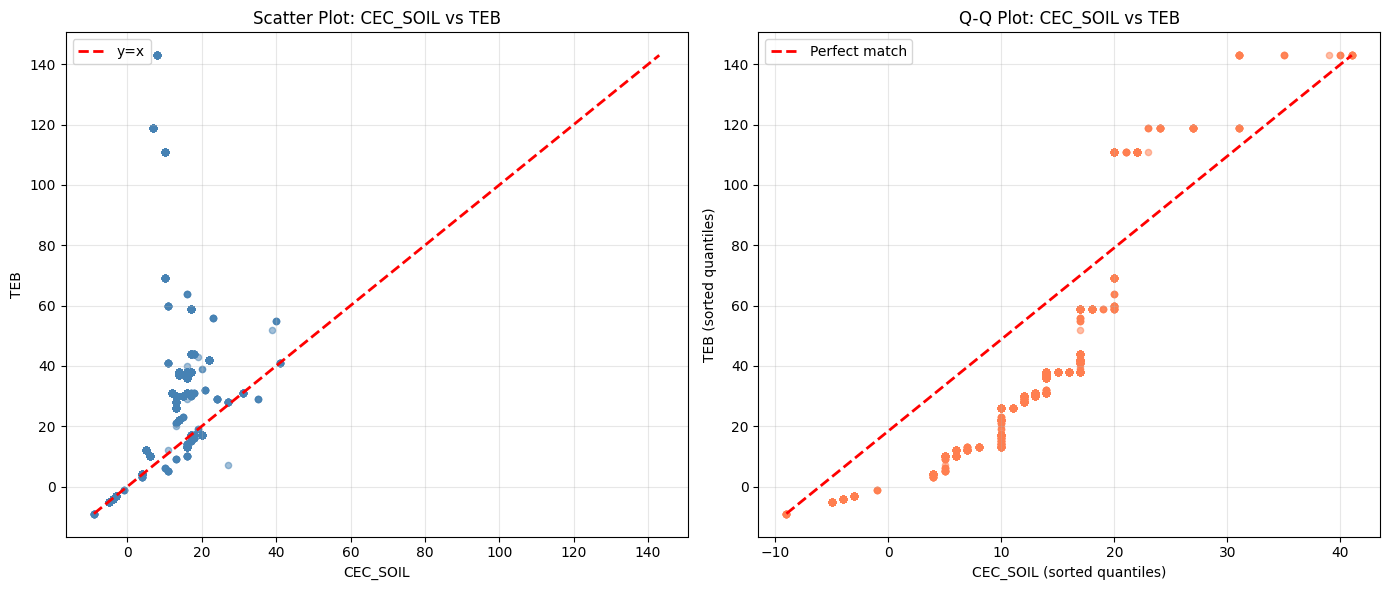

In [51]:
#CEC_SOIL vs TEB
pearsonSpearman(df_soil, 'CEC_SOIL', 'TEB')
corrPlot(df_soil, 'CEC_SOIL', 'TEB')

Pearson correlation between CEC_SOIL and BSAT: 0.9419 (p-value: 0.0000e+00)
Spearman correlation between CEC_SOIL and BSAT: 0.7252 (p-value: 0.0000) (p-value: 0.0000e+00)


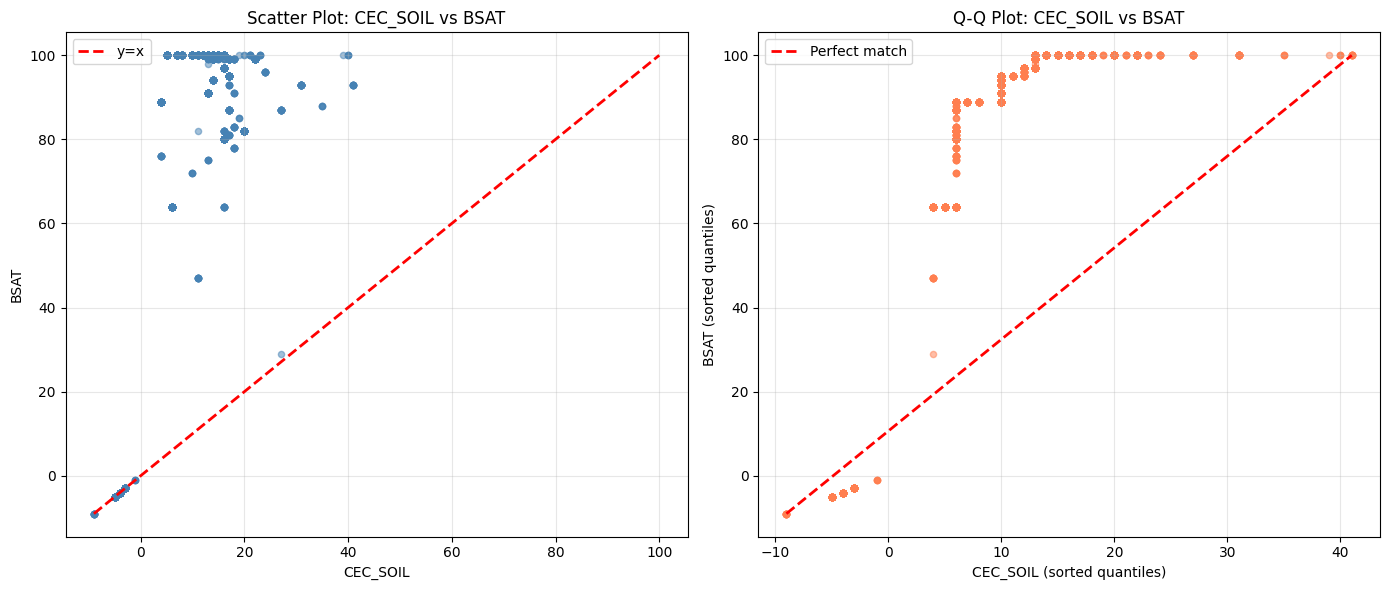

In [52]:
#CEC_SOIL vs BSAT
pearsonSpearman(df_soil, 'CEC_SOIL', 'BSAT')
corrPlot(df_soil, 'CEC_SOIL', 'BSAT')

Pearson correlation between CEC_SOIL and ALUM_SAT: 0.8162 (p-value: 0.0000e+00)
Spearman correlation between CEC_SOIL and ALUM_SAT: 0.7458 (p-value: 0.0000) (p-value: 0.0000e+00)


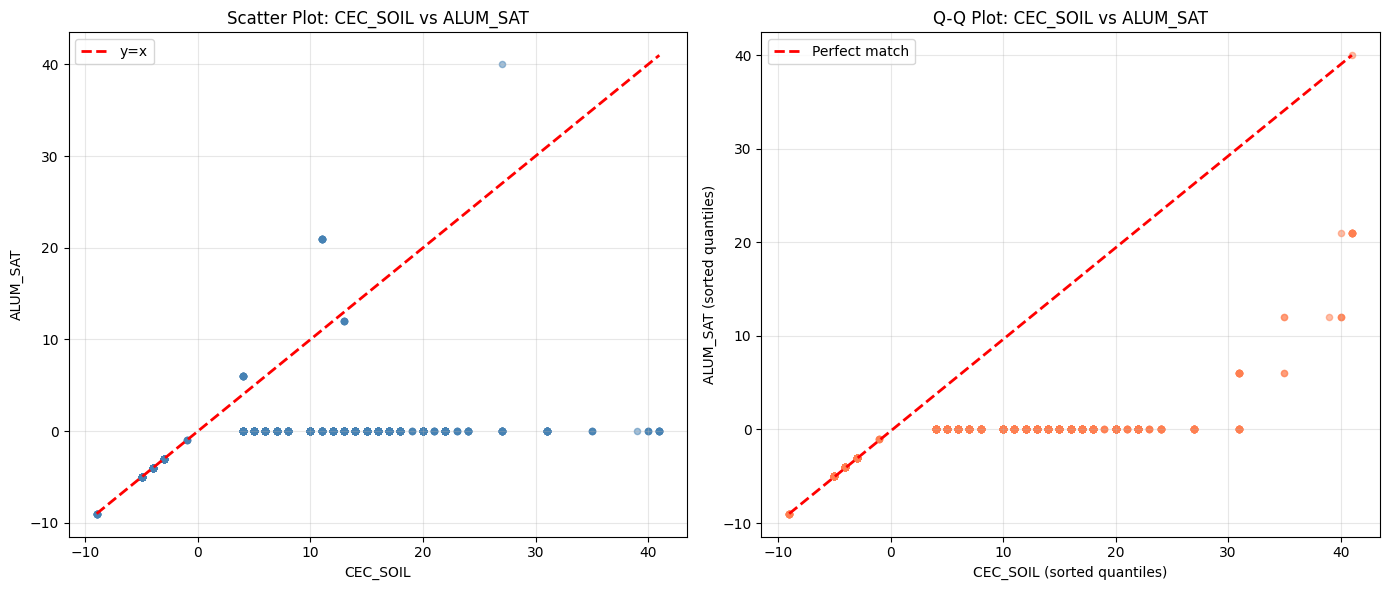

In [53]:
#CEC_SOIL vs ALUM_SAT
pearsonSpearman(df_soil, 'CEC_SOIL', 'ALUM_SAT')
corrPlot(df_soil, 'CEC_SOIL', 'ALUM_SAT')

Pearson correlation between CN_RATIO and ORG_CARBON: 0.9656 (p-value: 0.0000e+00)
Spearman correlation between CN_RATIO and ORG_CARBON: 0.8300 (p-value: 0.0000) (p-value: 0.0000e+00)


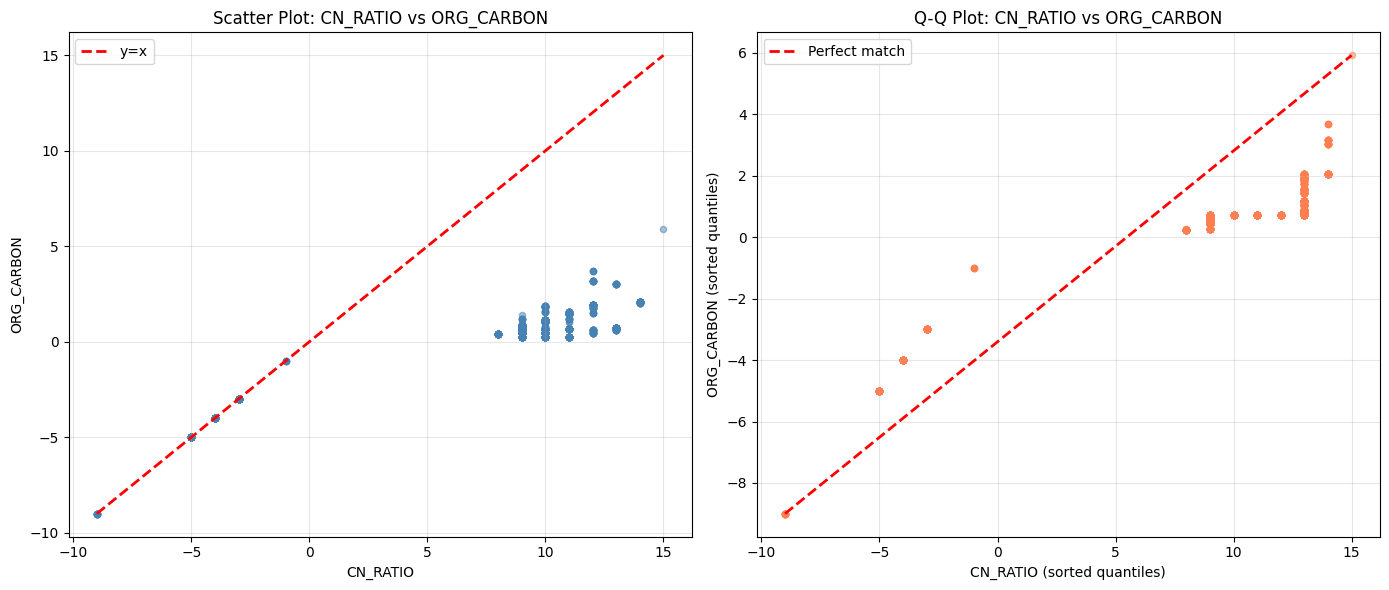

In [ ]:
# CN_RATIO and ORGAN_CARBON
pearsonSpearman(df_soil, 'CN_RATIO', 'ORG_CARBON')
corrPlot(df_soil, 'CN_RATIO', 'ORG_CARBON')

In [56]:
# ORG_CARBON', 'TOTAL_N'    CEC SOIL BSAT    CN_RATIO ORGAN_CARBON
#Pearson > 0.85

col_to_drop = ['TOTAL_N', 'BSAT', 'CN_RATIO']
df_soil = df_soil.drop(columns=col_to_drop)
print("Dropped columns due to high correlation:", col_to_drop)
print("Shape after dropping:", df_soil.shape)

Dropped columns due to high correlation: ['TOTAL_N', 'BSAT', 'CN_RATIO']
Shape after dropping: (23262, 22)
